# 📊 Análisis de Negocio para E-Commerce

## Proyecto de Business Analytics

### Objetivo
Analizar el rendimiento comercial, comportamiento de clientes y eficiencia operativa de un e-commerce utilizando Python y análisis de datos.

---

## Preguntas de negocio

- ¿Qué categorías generan mayores ingresos?
- ¿Cómo evolucionan las ventas en el tiempo?
- ¿Qué relación existe entre tiempos de entrega y satisfacción?
- ¿Qué características tienen los clientes más valiosos?
- ¿Qué oportunidades de mejora operativa existen?

---

## Dataset utilizado

Olist Brazilian E-Commerce Dataset

# 📦 Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Configuración visual
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# 📂 Carga de datasets

In [2]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translations = pd.read_csv('../data/product_category_name_translation.csv')

# 🔎 Exploración inicial de datos

In [3]:
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print('-' * 50)
    print(df.head())
    print(df.shape)


CUSTOMERS
--------------------------------------------------
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
(99441, 5)

ORDERS
--------------------------------------------------
                     

# 🧹 Limpieza y preparación de datos

In [4]:
# Conversión de fechas
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [5]:
# Verificación de valores nulos
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

# 🔗 Construcción del dataset maestro

In [6]:
# Merge productos + traducciones
products = products.merge(
    translations,
    on='product_category_name',
    how='left'
)

In [7]:
# Dataset principal
df = orders.merge(order_items, on='order_id', how='left')

df = df.merge(payments, on='order_id', how='left')

df = df.merge(reviews[['order_id', 'review_score']],
              on='order_id',
              how='left')

df = df.merge(products[['product_id',
                        'product_category_name_english']],
              on='product_id',
              how='left')

df = df.merge(customers[['customer_id',
                         'customer_state']],
              on='customer_id',
              how='left')

In [8]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,product_category_name_english,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,4.0,housewares,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,4.0,housewares,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,4.0,housewares,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,4.0,perfumery,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,5.0,auto,GO


# ⚙️ Creación de variables analíticas

In [9]:
# Revenue total
df['total_revenue'] = df['price'] + df['freight_value']

# Mes de compra
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Tiempo de entrega real
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Delay de entrega
df['delivery_delay'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

# 📈 KPIs principales del negocio

In [10]:
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_revenue = df['total_revenue'].sum()
avg_review = df['review_score'].mean()

print(f'Total de órdenes: {total_orders:,}')
print(f'Total de clientes: {total_customers:,}')
print(f'Ingresos totales: ${total_revenue:,.2f}')
print(f'Review promedio: {avg_review:.2f}')

Total de órdenes: 99,441
Total de clientes: 99,441
Ingresos totales: $16,643,731.30
Review promedio: 4.02


# 💰 Análisis de ingresos

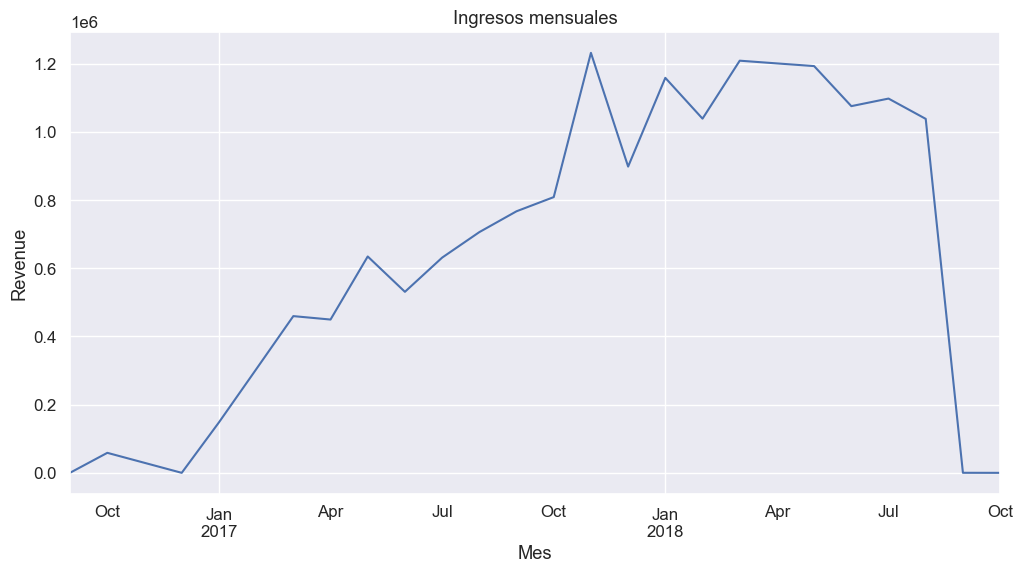

In [11]:
monthly_revenue = df.groupby('purchase_month')['total_revenue'].sum()

monthly_revenue.plot(figsize=(12,6))

plt.title('Ingresos mensuales')
plt.xlabel('Mes')
plt.ylabel('Revenue')

plt.show()

# 🏆 Categorías con mayores ingresos

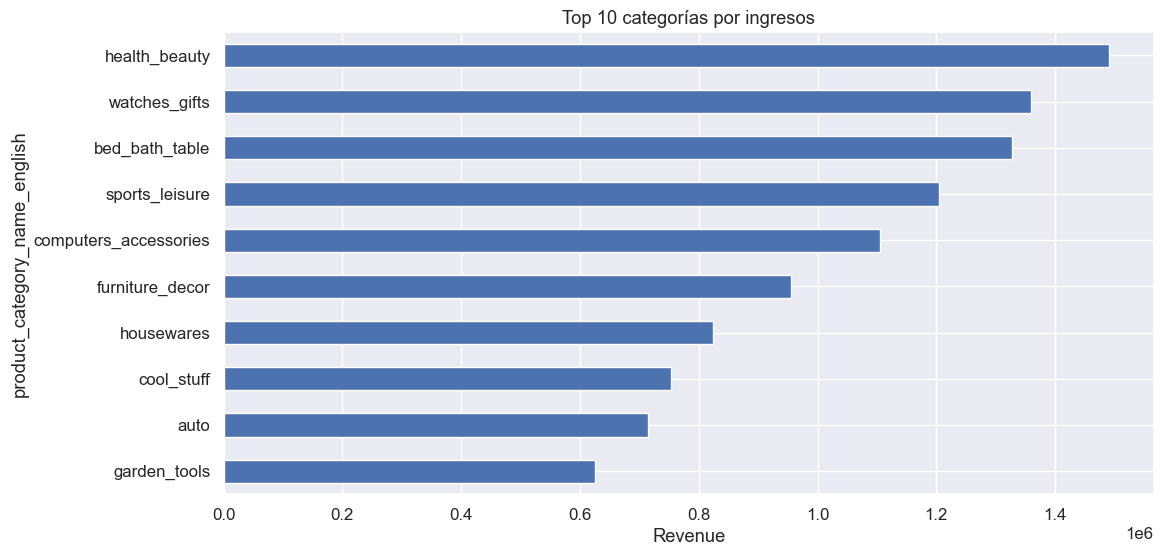

In [12]:
top_categories = (
    df.groupby('product_category_name_english')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_categories.sort_values().plot(kind='barh')

plt.title('Top 10 categorías por ingresos')
plt.xlabel('Revenue')

plt.show()

# 🚚 Relación entre entregas y satisfacción

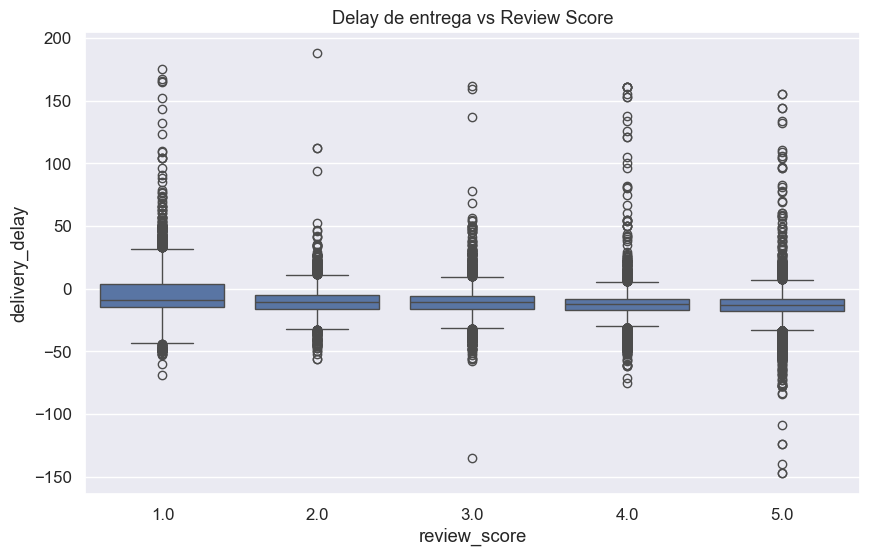

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['review_score'],
    y=df['delivery_delay']
)

plt.title('Delay de entrega vs Review Score')

plt.show()

# 🧠 Insights de negocio

## Principales hallazgos

### 1. Revenue concentrado
Un pequeño grupo de categorías concentra gran parte de los ingresos del e-commerce.

### 2. Impacto logístico
Los retrasos en las entregas afectan negativamente la satisfacción del cliente.

### 3. Importancia operativa
La logística tiene un impacto directo en la experiencia del usuario y potencialmente en la retención.

### 4. Oportunidades
Existen categorías con alto volumen pero baja satisfacción, lo cual representa oportunidades de mejora.

# ✅ Conclusiones

El análisis permitió identificar relaciones importantes entre revenue, experiencia del cliente y performance operativa.

Los resultados sugieren que mejorar los tiempos de entrega y optimizar categorías estratégicas podría generar mejoras tanto en satisfacción como en ingresos.

---

## Próximos pasos

- Construcción de dashboard en Power BI
- Segmentación avanzada de clientes
- Predicción de churn
- Forecasting de ventas